In [33]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("train.csv", low_memory=False)

print("Initial Shape:", df.shape)

Initial Shape: (100000, 28)


In [5]:
df.replace(['_', 'NA', 'NaN'], np.nan, inplace=True)

In [7]:
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(r'0x[0-9a-fA-F]+', '', regex=True)

In [9]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))
    else:
        df[col] = pd.to_numeric(df[col], errors='coerce')


In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df.fillna(0, inplace=True)

In [13]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [15]:
y = pd.to_numeric(y, errors='coerce')
y = y.fillna(y.mode()[0]).astype(int)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
rf = RandomForestClassifier(
    n_estimators=300,     # more trees → better accuracy
    max_depth=12,         # prevent overfitting
    min_samples_split=5,
    random_state=42)

In [23]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=12, min_samples_split=5, n_estimators=300,
                       random_state=42)

In [29]:
rf.fit(X_train, y_train)     # Train model
y_pred = rf.predict(X_test)  # THIS LINE IS MISSING OR NOT RUN

In [31]:
acc = accuracy_score(y_test, y_pred)

print("\n===== RANDOM FOREST RESULTS =====")
print("Accuracy:", acc)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


===== RANDOM FOREST RESULTS =====
Accuracy: 0.7185

Confusion Matrix:
 [[2364   13 1150]
 [ 403 3684 1787]
 [1140 1137 8322]]

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.67      0.64      3527
           1       0.76      0.63      0.69      5874
           2       0.74      0.79      0.76     10599

    accuracy                           0.72     20000
   macro avg       0.70      0.69      0.70     20000
weighted avg       0.72      0.72      0.72     20000



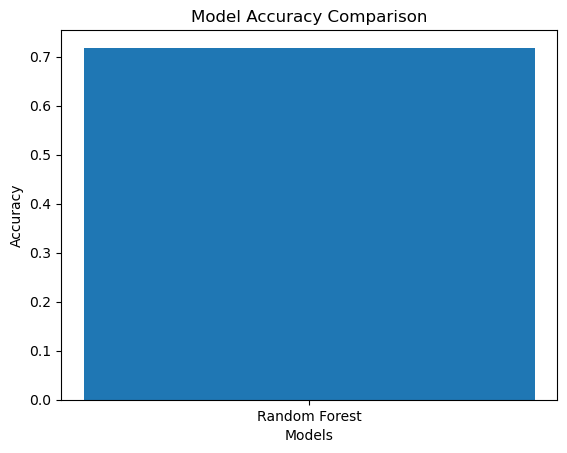

In [37]:
# Store your accuracy (after running model)
model_names = ["Random Forest"]
accuracies = [acc]

plt.figure()
plt.bar(model_names, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()

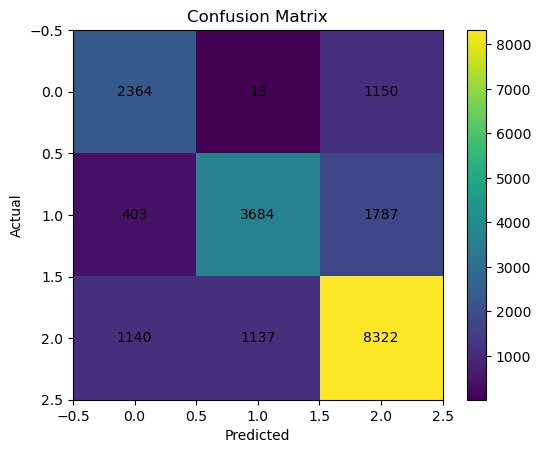

In [39]:
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

plt.xlabel("Predicted")
plt.ylabel("Actual")

# Show values
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

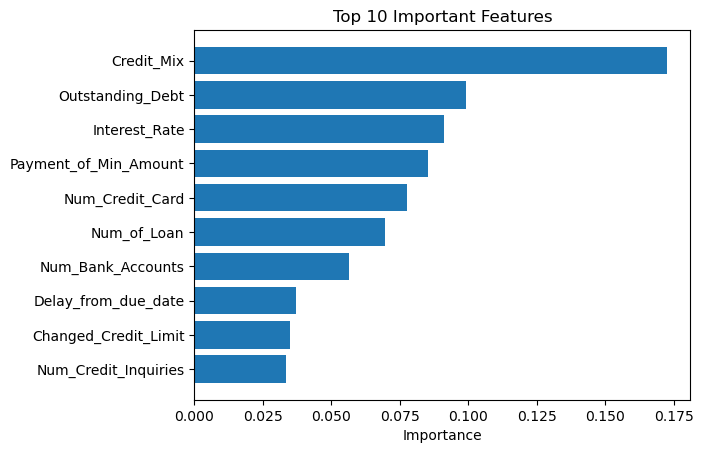

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf.feature_importances_

feature_names = X.columns

# Create dataframe
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure()
plt.barh(feat_df['Feature'], feat_df['Importance'])
plt.xlabel("Importance")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

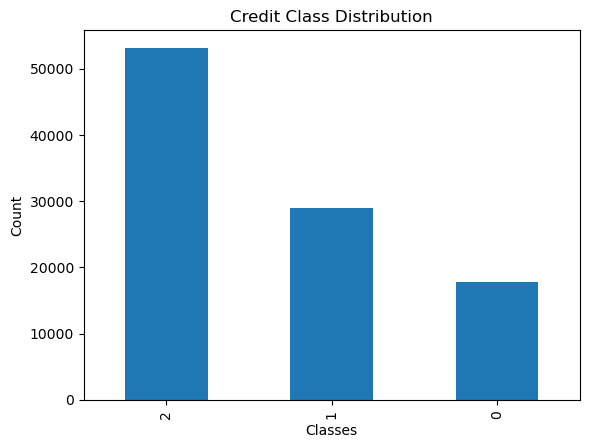

In [43]:
y.value_counts().plot(kind='bar')
plt.title("Credit Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()